# 10 — Spectral-Norm Deep Dive

**Winner: C** (~9.95 J) — closely followed by C++ (~11.9 J, 1.19×).

Notable patterns:
- **C edges out C++** here — `spectral-norm` is a dense linear algebra benchmark (approximate largest eigenvalue via power iteration). C's simpler compilation model can produce slightly tighter inner loops.
- **The top 9 languages are tightly packed (10–35 J)**: C, C++, C#, Rust, Swift, Go, Haskell, Dart, F# — all within 3.5× of each other.
- **Haskell (7th, ~18.8 J)** performs well again on this numerical benchmark, unlike `k-nucleotide` or `n-body`.
- **Python is worst** (~4 142 J, 416× worse than C) — the largest ratio in the dataset after `mandelbrot`.
- **Erlang (13th, ~341 J)** starts the slow tier — a 34× gap from C, reflecting Erlang's lack of native floating-point vectorisation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

BENCHMARK = 'spectral-norm'
RUNS_CSV  = Path('../results/results_clean_runs.csv')
MEAN_CSV  = Path('../results/results_clean.csv')
FIGS_DIR  = Path('../results/figs/spectral_norm')
FIGS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'figure.dpi': 150, 'savefig.dpi': 300,
})

def save(name): plt.savefig(FIGS_DIR / f'{name}.pdf', bbox_inches='tight'); plt.show()
def find_col(df, kw): return next(c for c in df.columns if kw in c)
unit = lambda col: col.rsplit('-', 1)[-1].upper()

---
## 1. Load data

In [2]:
bt_runs  = pd.read_csv(RUNS_CSV)
bt_runs  = bt_runs[bt_runs['benchmark'] == BENCHMARK].copy()
bt_means = pd.read_csv(MEAN_CSV)
bt_means = bt_means[bt_means['benchmark'] == BENCHMARK].set_index('language')

COL_CPU_E  = find_col(bt_runs, 'cpu_energy')
COL_MEM_E  = find_col(bt_runs, 'memory_energy')
COL_CARBON = find_col(bt_runs, 'cpu_carbon')
COL_TIME   = find_col(bt_runs, 'phase_time')

print(f'Per-run rows: {len(bt_runs)} | Mean rows: {len(bt_means)}')
bt_means[[COL_CPU_E, COL_TIME]].sort_values(COL_CPU_E).round(3)

Per-run rows: 150 | Mean rows: 18


,cpu_energy_rapl_msr_component-package_0-j,phase_time_syscall_system-system-s
language,,
c,9.661,0.420
cpp,11.482,0.482
csharp,15.291,0.596
rust,16.822,0.598
swift,16.879,0.593
go,18.296,0.673
haskell,18.790,0.707
fsharp,19.684,0.735
dart,19.772,0.695


---
## 2. Strip plot — per-run consistency

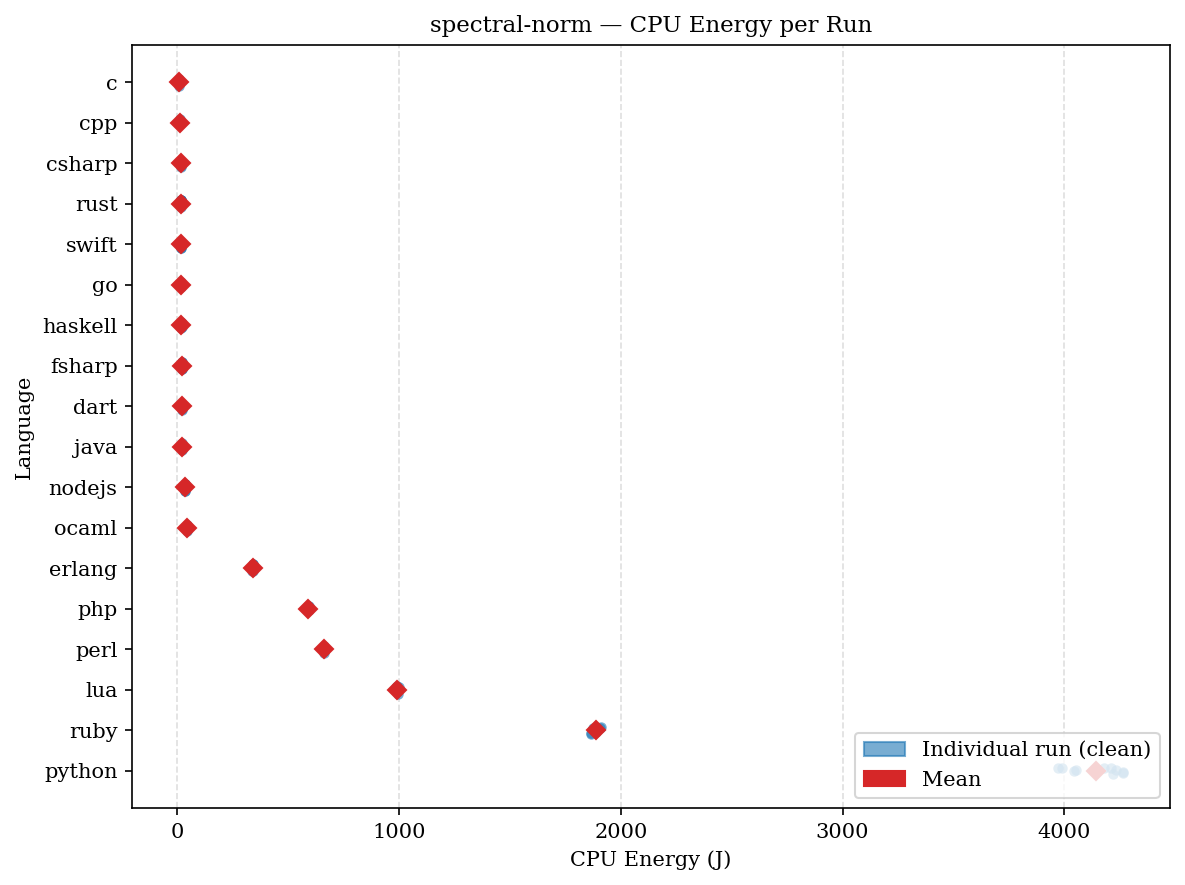

In [3]:
order = bt_means[COL_CPU_E].sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(8, 6))
sns.stripplot(data=bt_runs, x=COL_CPU_E, y='language', order=order,
              jitter=True, alpha=0.6, size=5, color='#1f77b4', ax=ax)
for i, lang in enumerate(order):
    ax.plot(bt_means.loc[lang, COL_CPU_E], i, marker='D', color='#d62728', markersize=6, zorder=5)

ax.legend(handles=[
    mpatches.Patch(color='#1f77b4', alpha=0.6, label='Individual run (clean)'),
    mpatches.Patch(color='#d62728', label='Mean'),
], loc='lower right')
ax.set_xlabel(f'CPU Energy ({unit(COL_CPU_E)})')
ax.set_ylabel('Language')
ax.set_title(f'{BENCHMARK} — CPU Energy per Run')
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
save('stripplot_cpu_energy')

---
## 3. Ranked bar — two panels (full + top-9 zoom)

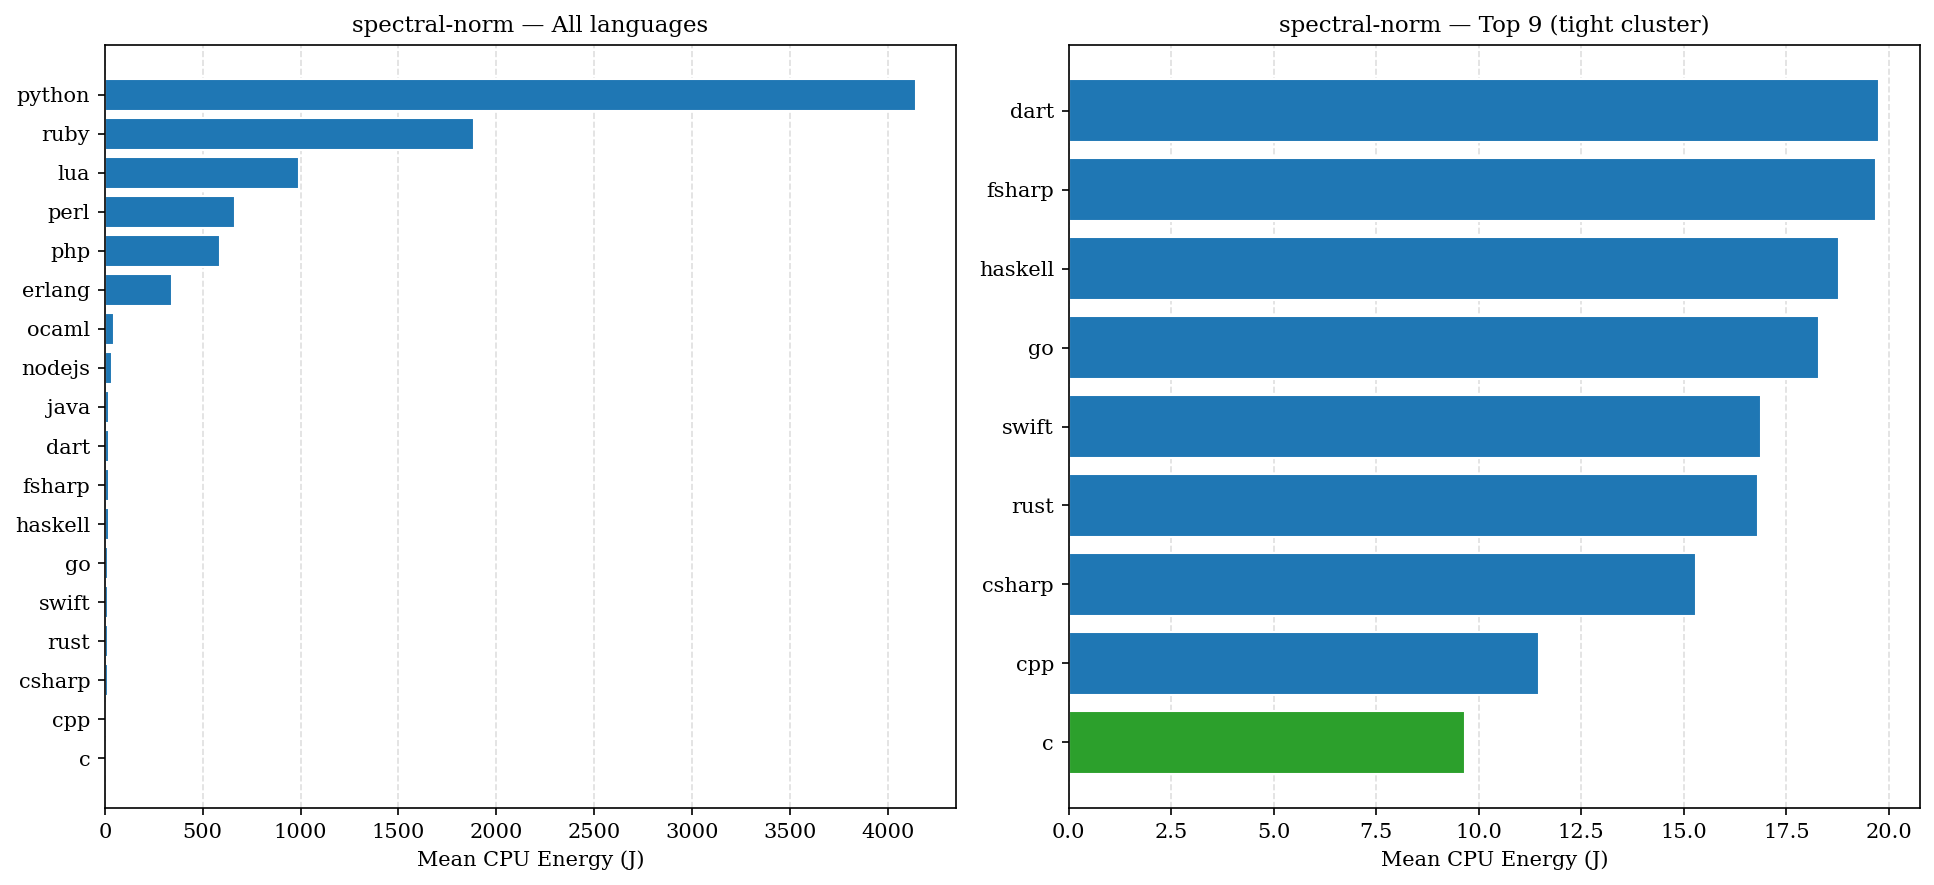

In [4]:
means = bt_means.sort_values(COL_CPU_E)
winner = means.index[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

colors_full = ['#2ca02c'] + ['#1f77b4'] * (len(means) - 1)
axes[0].barh(means.index, means[COL_CPU_E], color=colors_full, edgecolor='white')
axes[0].set_xlabel(f'Mean CPU Energy ({unit(COL_CPU_E)})')
axes[0].set_title(f'{BENCHMARK} — All languages')
axes[0].xaxis.grid(True, linestyle='--', alpha=0.4)
axes[0].set_axisbelow(True)

top9 = means.head(9)
colors_top = ['#2ca02c'] + ['#1f77b4'] * 8
axes[1].barh(top9.index, top9[COL_CPU_E], color=colors_top, edgecolor='white')
axes[1].set_xlabel(f'Mean CPU Energy ({unit(COL_CPU_E)})')
axes[1].set_title(f'{BENCHMARK} — Top 9 (tight cluster)')
axes[1].xaxis.grid(True, linestyle='--', alpha=0.4)
axes[1].set_axisbelow(True)

plt.tight_layout()
save('bar_cpu_energy')

---
## 4. Normalised to winner

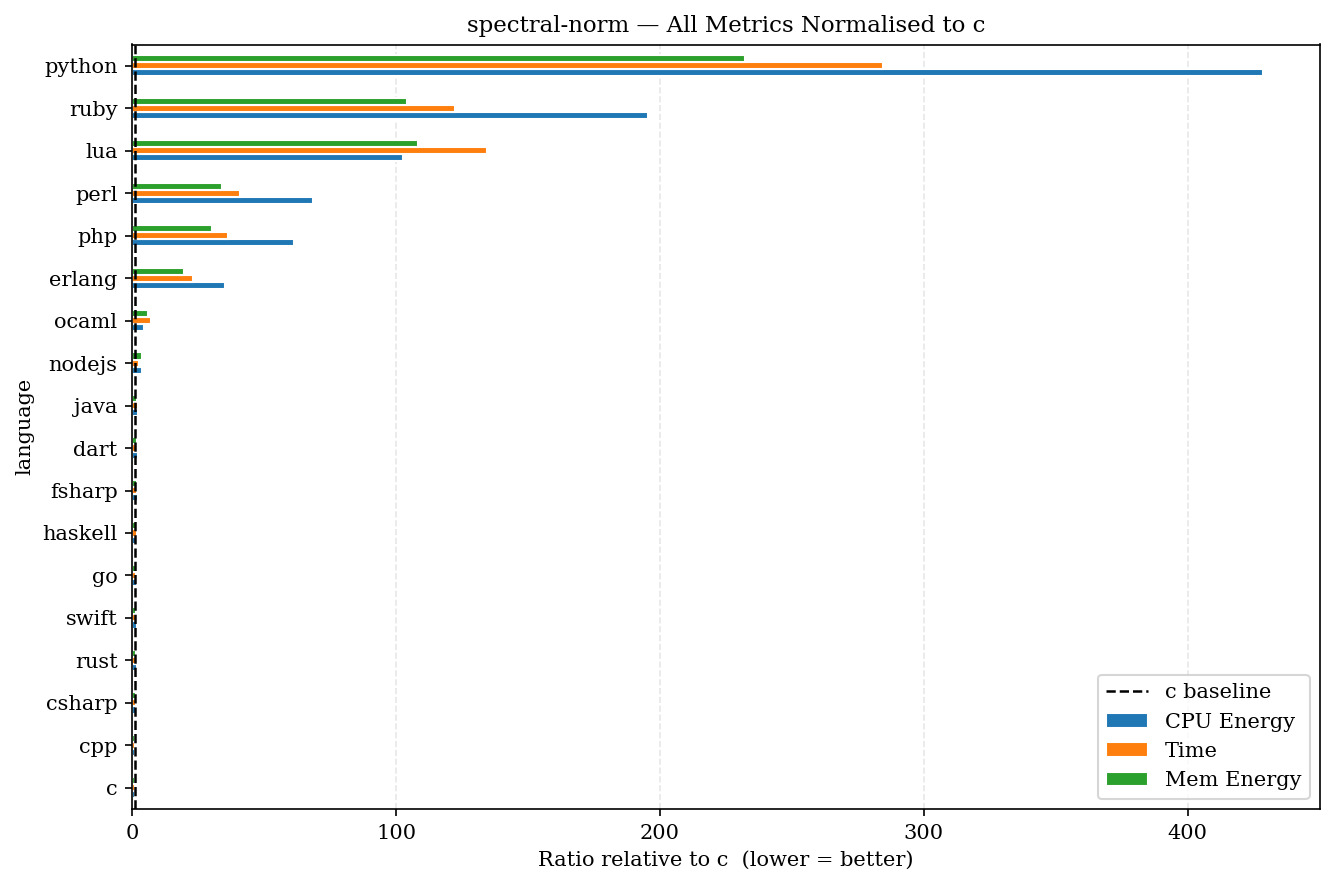

In [5]:
subset = means[[COL_CPU_E, COL_TIME, COL_MEM_E]]
ratio = subset.div(subset.loc[winner])
ratio.columns = ['CPU Energy', 'Time', 'Mem Energy']

fig, ax = plt.subplots(figsize=(9, 6))
ratio.plot(kind='barh', ax=ax, edgecolor='white')
ax.axvline(1.0, color='black', linewidth=1.2, linestyle='--', label=f'{winner} baseline')
ax.set_xlabel(f'Ratio relative to {winner}  (lower = better)')
ax.set_title(f'{BENCHMARK} — All Metrics Normalised to {winner}')
ax.legend(loc='lower right')
ax.xaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
save('normalised')

---
## 5. Energy vs. Time scatter

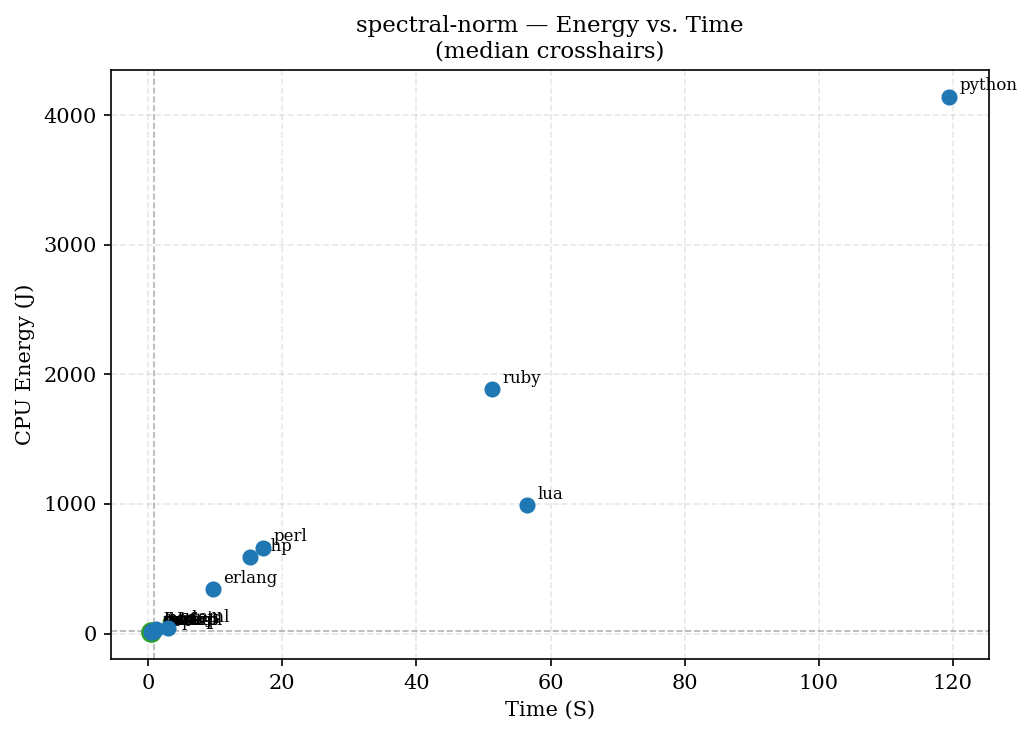

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
for lang, row in means.iterrows():
    color = '#2ca02c' if lang == winner else '#1f77b4'
    ax.scatter(row[COL_TIME], row[COL_CPU_E], color=color, s=80 if lang == winner else 45, zorder=3)
    ax.annotate(lang, (row[COL_TIME], row[COL_CPU_E]),
                textcoords='offset points', xytext=(5, 3), fontsize=8,
                color='#2ca02c' if lang == winner else 'black',
                fontweight='bold' if lang == winner else 'normal')

ax.axvline(means[COL_TIME].median(), color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(means[COL_CPU_E].median(), color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_xlabel(f'Time ({unit(COL_TIME)})')
ax.set_ylabel(f'CPU Energy ({unit(COL_CPU_E)})')
ax.set_title(f'{BENCHMARK} — Energy vs. Time\n(median crosshairs)')
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
save('scatter_energy_vs_time')

---
## 6. Summary table

In [7]:
summary = means[[COL_CPU_E, COL_TIME, COL_MEM_E, COL_CARBON]].copy()
summary.columns = [f'CPU Energy ({unit(COL_CPU_E)})', f'Time ({unit(COL_TIME)})',
                   f'Mem Energy ({unit(COL_MEM_E)})', f'CPU Carbon ({unit(COL_CARBON)})']
summary.round(4)

,CPU Energy (J),Time (S),Mem Energy (J),CPU Carbon (G)
language,,,,
c,9.6609,0.4195,0.1492,0.0009
cpp,11.4817,0.4823,0.1758,0.0011
csharp,15.2906,0.5958,0.2143,0.0014
rust,16.8215,0.5985,0.2149,0.0016
swift,16.8790,0.5928,0.2129,0.0016
go,18.2963,0.6728,0.2424,0.0017
haskell,18.7895,0.7066,0.2470,0.0017
fsharp,19.6844,0.7355,0.2662,0.0018
dart,19.7722,0.6946,0.2566,0.0018
